In [1]:
import kagglehub

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Define the specific CSV file within the dataset
file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Load the dataset into a pandas DataFrame
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "pavansubhasht/ibm-hr-analytics-attrition-dataset",
  file_path
)

# Display the first 5 records
df.head()


/tmp/ipykernel_3216/1334955117.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split , cross_val_score , GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score

In [4]:
df.shape

(1470, 35)

In [5]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [52]:
le = LabelEncoder()
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include = 'object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])


In [53]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   int64
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null 

In [54]:
corr = df_encoded.corr()
print(corr)

                               Age  Attrition  BusinessTravel  DailyRate  \
Age                       1.000000  -0.159205        0.024751   0.010661   
Attrition                -0.159205   1.000000        0.000074  -0.056652   
BusinessTravel            0.024751   0.000074        1.000000  -0.004086   
DailyRate                 0.010661  -0.056652       -0.004086   1.000000   
Department               -0.031882   0.063991       -0.009044   0.007109   
DistanceFromHome         -0.001686   0.077924       -0.024469  -0.004985   
Education                 0.208034  -0.031373        0.000757  -0.016806   
EducationField           -0.040873   0.026846        0.023724   0.037709   
EmployeeCount                  NaN        NaN             NaN        NaN   
EmployeeNumber           -0.010145  -0.010577       -0.015578  -0.050990   
EnvironmentSatisfaction   0.010146  -0.103369        0.004174   0.018355   
Gender                   -0.036311   0.029453       -0.032981  -0.011716   
HourlyRate  

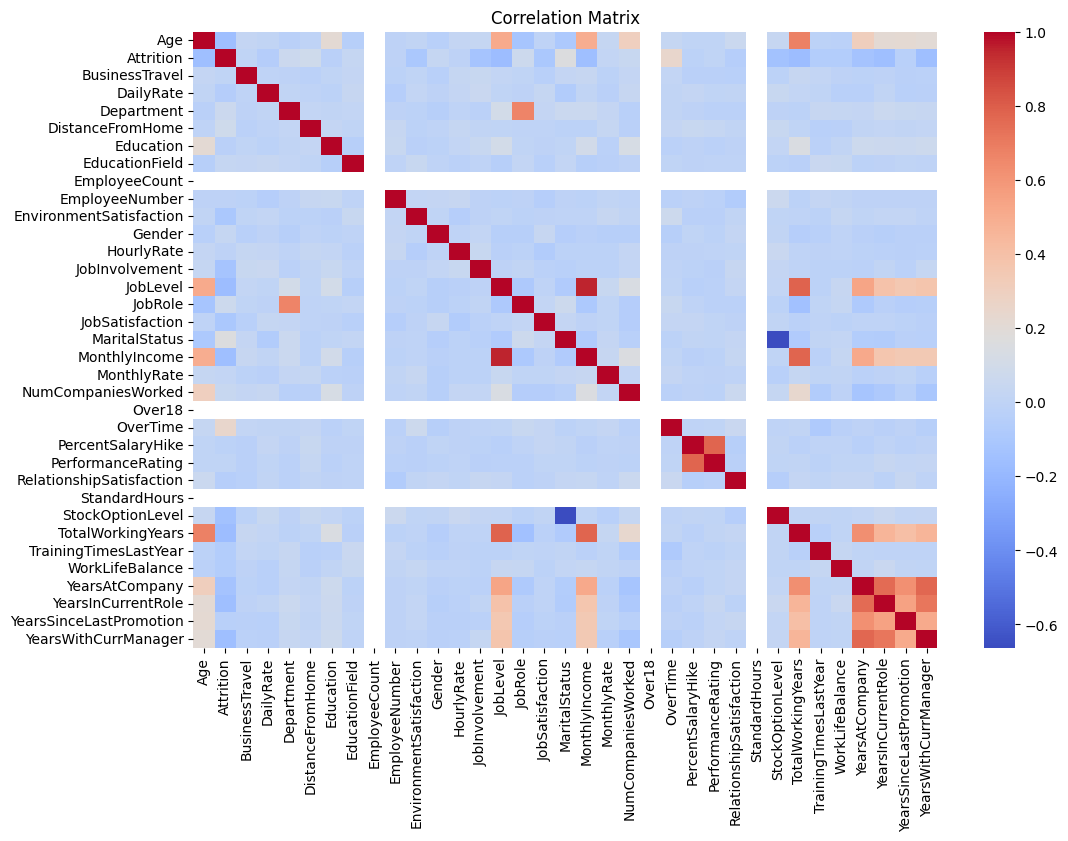

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [56]:
df_encoded.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1, inplace=True)

In [57]:
features = [
    'OverTime',
    'MonthlyIncome',
    'JobLevel',
    'TotalWorkingYears',
    'YearsAtCompany',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'WorkLifeBalance',
    'DistanceFromHome'
]

X = df_encoded[features]
y = df_encoded['Attrition']

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [59]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_resampled, y_resampled)

best_model = grid.best_estimator_

In [18]:
!pip install imblearn 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [64]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

# 1. Create a range from 0.00 to 1.00 with 0.01 gaps
thresholds = np.arange(0.0, 1.01, 0.01)
data = []

for t in thresholds:
    # Apply threshold to probabilities
    y_pred_t = (y_prob >= t).astype(int)
    
    # Calculate Precision, Recall, and F1 (Binary focusing on '1'/Yes)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred_t, average='binary', zero_division=0)
    
    data.append({'Threshold': t, 'Precision': p, 'Recall': r, 'F1_Score': f1})

# 2. Convert to DataFrame for easy viewing
report_df = pd.DataFrame(data)

# 3. Find and print the best threshold based on F1 Score
best_idx = report_df['F1_Score'].idxmax()
best_row = report_df.iloc[best_idx]

print(f"--- Optimal Threshold Found ---")
print(f"Threshold: {best_row['Threshold']:.2f}")
print(f"F1 Score:  {best_row['F1_Score']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall:    {best_row['Recall']:.4f}")

# 4. Optional: View the top 10 best performing thresholds
report_df.sort_values(by='F1_Score', ascending=False).head(10)


--- Optimal Threshold Found ---
Threshold: 0.53
F1 Score:  0.4381
Precision: 0.3966
Recall:    0.4894


,Threshold,Precision,Recall,F1_Score
53,0.53,0.396552,0.489362,0.438095
52,0.52,0.389831,0.489362,0.433962
51,0.51,0.383333,0.489362,0.429907
48,0.48,0.357143,0.531915,0.427350
47,0.47,0.352113,0.531915,0.423729
50,0.50,0.358209,0.510638,0.421053
42,0.42,0.325581,0.595745,0.421053
46,0.46,0.337662,0.553191,0.419355
44,0.44,0.325301,0.574468,0.415385
41,0.41,0.318182,0.595745,0.414815


In [66]:
# Use the best threshold you just found
final_threshold = 0.53 
y_final_pred = (y_prob > final_threshold).astype(int)

# Now print the report for the OPTIMIZED model
print(classification_report(y_test, y_final_pred))
print(confusion_matrix(y_test, y_final_pred))


              precision    recall  f1-score   support

           0       0.89      0.86      0.88       247
           1       0.39      0.47      0.43        47

    accuracy                           0.80       294
   macro avg       0.64      0.67      0.65       294
weighted avg       0.81      0.80      0.81       294

[[213  34]
 [ 25  22]]


In [65]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7482993197278912
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       247
           1       0.33      0.55      0.41        47

    accuracy                           0.75       294
   macro avg       0.62      0.67      0.63       294
weighted avg       0.81      0.75      0.77       294

[[194  53]
 [ 21  26]]


In [67]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=3
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb = (y_prob_xgb > 0.45).astype(int)

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

# Logistic Regression with scaling
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000))
])

# Voting classifier
voting = VotingClassifier(
    estimators=[
        ('rf', best_model),
        ('lr', lr_pipeline)
    ],
    voting='soft'
)

voting.fit(X_resampled, y_resampled)

,estimators,"[('rf', ...), ('lr', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,300
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1


In [70]:
y_prob = voting.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.53).astype(int)

In [71]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.83      0.86       247
           1       0.36      0.51      0.42        47

    accuracy                           0.78       294
   macro avg       0.63      0.67      0.64       294
weighted avg       0.81      0.78      0.79       294



In [72]:
# Use final selected model (Random Forest)
final_model = best_model   # from GridSearch

# Generate risk score
df['RiskScore'] = final_model.predict_proba(X)[:,1] * 100

# Categorize risk
def risk_category(score):
    if score < 30:
        return "Low"
    elif score < 70:
        return "Medium"
    else:
        return "High"

df['RiskCategory'] = df['RiskScore'].apply(risk_category)

# Select final columns for dashboard
final_df = df[[
    'EmployeeNumber',
    'Department',
    'MonthlyIncome',
    'YearsAtCompany',
    'Attrition',
    'RiskScore',
    'RiskCategory'
]]

# Export for Power BI
final_df.to_csv("final_attrition_dashboard.csv", index=False)

print("Final dataset ready for Power BI!")

Final dataset ready for Power BI!
